# Figure 6 — the effective dimensions of transcriptome-wide response

Computable panels: **A** (participation-ratio / effective-dimension distributions of the response across control-covariance PCs), **B** (response-fraction PC heatmaps), **C/D** (μ-axis vs orthogonal response decomposition on the control-mean/total-RNA axis), **E** (GSEA/Enrichr of μ-axis-dominated targets), **F** (standardized growth-scaling factor `c`), **G** (mean participation ratio vs mean forward ΔR² per dataset). **H/I** (effective number of driving genes) reuse the suppl engine `run_figS15`. Engine: `notebooks/src/run_fig6.py`.

In [1]:
import os, sys
import importlib as _il
try:
    _std_tqdm = _il.import_module('tqdm.std').tqdm
    for _m in ('tqdm','tqdm.auto','tqdm.notebook','tqdm.autonotebook'):
        try: _il.import_module(_m).tqdm = _std_tqdm
        except Exception: pass
except Exception: pass
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) in ("main","suppl") else os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.run_fig6 import *
from src.logutil import route_logs
DATA_DIR = os.environ["CIPHER_DATA_DIR"]
SUPPL = os.path.join(DATA_DIR, "suppl")
OUTDIR = os.environ.get("SUPPL_OUT", "resources/repro/fig6")
os.makedirs(OUTDIR, exist_ok=True)
route_logs("fig6_effective_dims")
import src.run_fig6 as R
R.__dict__.update({k: v for k, v in globals().items() if k.isupper() or k in ("DATA_DIR","OUTDIR")})

[logs] verbose output -> ../../resources/repro/fig6/logs/fig6_effective_dims.log


## Compute participation ratios + response fractions (all CRISPRi/a datasets)

In [2]:
R.compute_all()

## Panels A / B — participation-ratio distributions + PC-fraction heatmaps

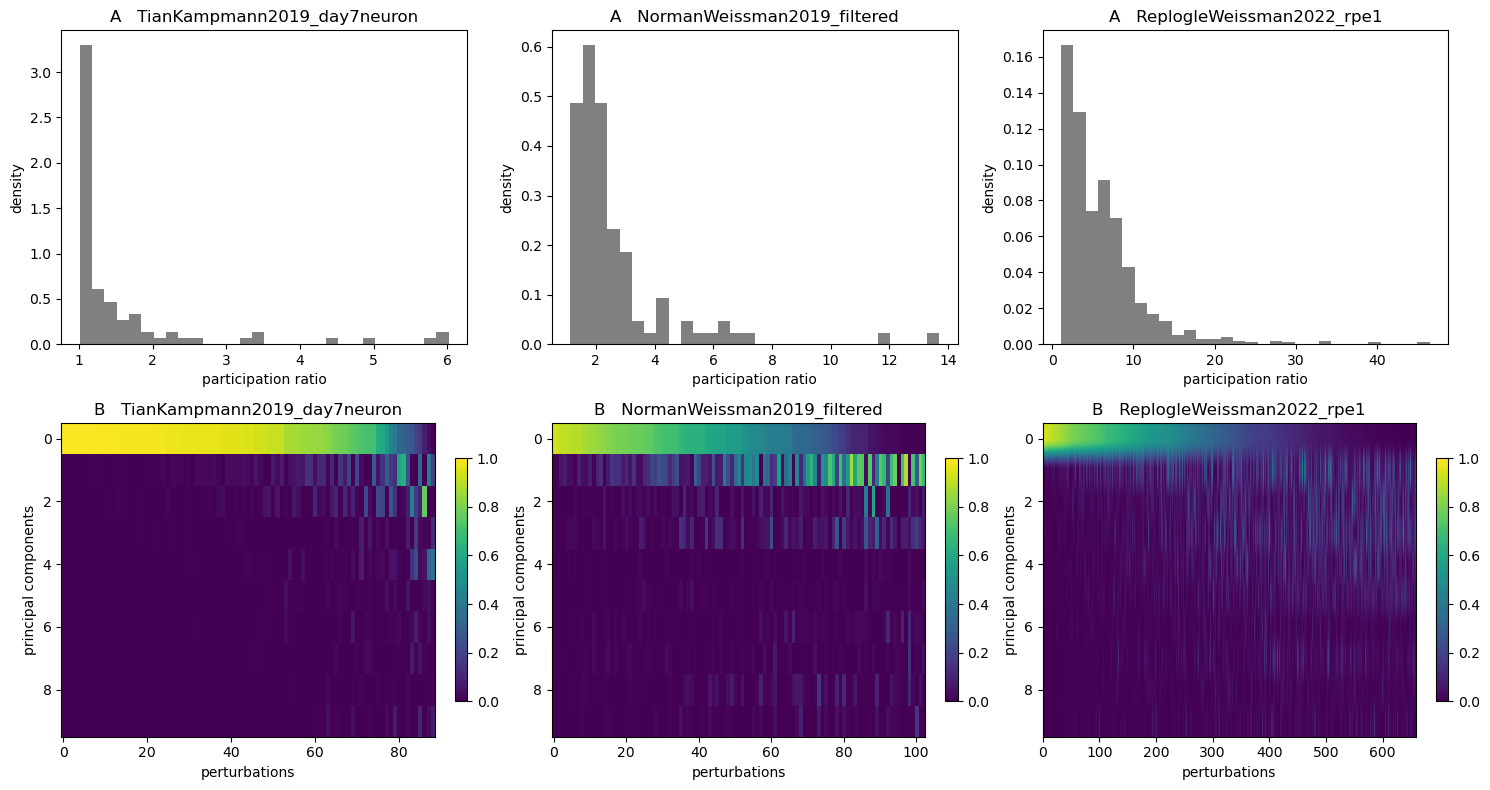

In [3]:
R.panel_ab()

## Panel G — mean participation ratio vs mean ΔR²

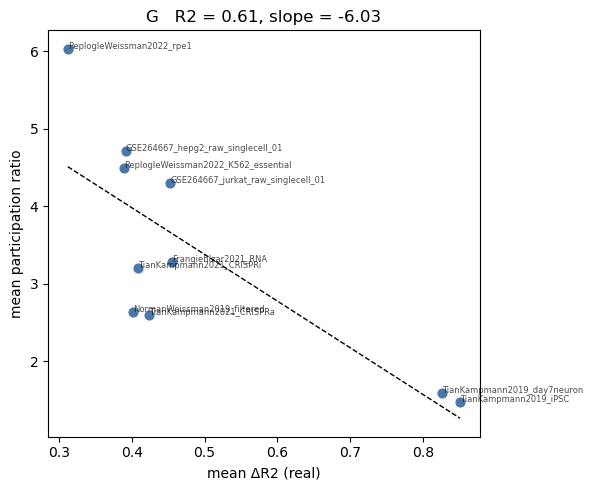

In [4]:
R.panel_g()

## Panels I and K

**I** — effective number of genes contributing to the true perturbed gene's response (Shannon effective count per perturbation, pooled across datasets, log axis), read from the figS15 sweep table already on disk. **K** — median mLISI on the 2D UMAP (k=50) for synthetic data built from raw vs library-size-normalised counts (max attainable = 2).

> **H** and **L** are not reproduced here: H needs a gene-by-gene contribution entropy that no saved output carries, and L's per-perturbation raw-vs-library-size Pearson values were never persisted by the scDesign3 (R) pipeline.

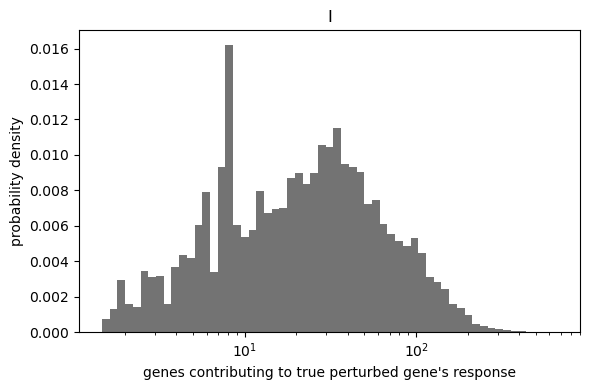

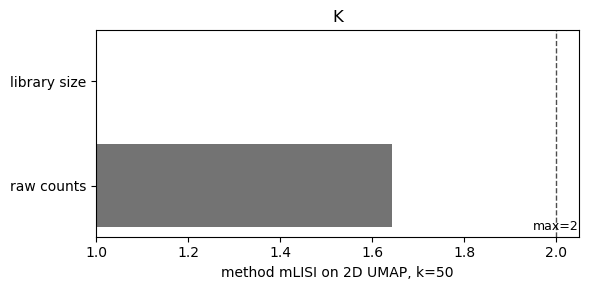

{'raw counts': 1.642336, 'library size': 1.0}

In [5]:
R.panel_i()
R.panel_k()

## Panels C–F — μ-axis (control-mean / total-RNA) decomposition + GSEA

Each perturbation's response `dx` is split into its component along the **control-mean expression axis** μ (the global "total-RNA" / library-scaling direction) and the μ-orthogonal residual. **C** plots the μ-axis Pearson gain (full − residual) vs the residual Pearson, colored by the fraction of `dx` norm² along μ; **D** highlights the top-150 by μ-axis gain; **E** is the Hallmark/KEGG enrichment (gseapy Enrichr) of the μ-axis-dominated targets; **F** is the standardized growth-scaling factor `c = 1 − dx/μ` per target.

> **J/K/L — scDesign3 raw vs library-size mixing (mLISI) + accuracy** live in `scratch/functional/scdesign3_cipher_fig6.ipynb`; they need an R/scDesign3 environment to regenerate the synthetic data and are not cleaned into `notebooks/src`.

In [6]:
R.compute_mu_axis()

,dataset,group,perturbation,target,frac_mu,pearson_full,pearson_residual,mu_axis_gain,c
0,FrangiehIzar2021_RNA,CRISPRi,ACTA2,ACTA2,0.760764,0.836127,0.028746,0.807381,0.910171
1,FrangiehIzar2021_RNA,CRISPRi,B2M,B2M,0.839136,0.862070,0.003994,0.858076,0.871562
2,FrangiehIzar2021_RNA,CRISPRi,A2M,A2M,0.913264,0.607996,0.794788,-0.186792,0.876134
3,FrangiehIzar2021_RNA,CRISPRi,AEBP1,AEBP1,0.829692,0.884557,0.011653,0.872905,0.907898
4,FrangiehIzar2021_RNA,CRISPRi,CD59,CD59,0.722818,0.783869,0.027921,0.755948,0.955275
...,...,...,...,...,...,...,...,...,...
19211,schemidt_etal_2022_crispra_perturbseq,CRISPRa,AKAP12,AKAP12,0.038300,0.152071,0.074245,0.077826,0.976335
19212,schemidt_etal_2022_crispra_perturbseq,CRISPRa,FOSL1,FOSL1,0.417967,0.182243,0.258966,-0.076723,0.876500
19213,schemidt_etal_2022_crispra_perturbseq,CRISPRa,GATA3,GATA3,0.040055,0.235190,0.077270,0.157920,0.932049
19214,schemidt_etal_2022_crispra_perturbseq,CRISPRa,LHX4,LHX4,0.878719,0.756884,0.093033,0.663851,0.646380


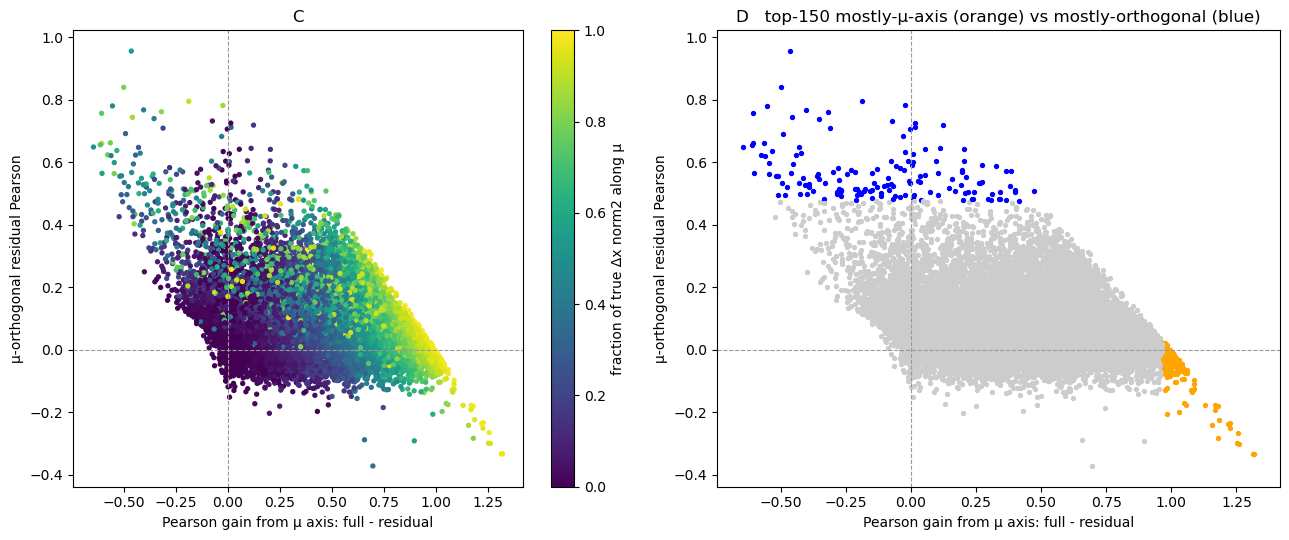

In [7]:
R.panel_cd()

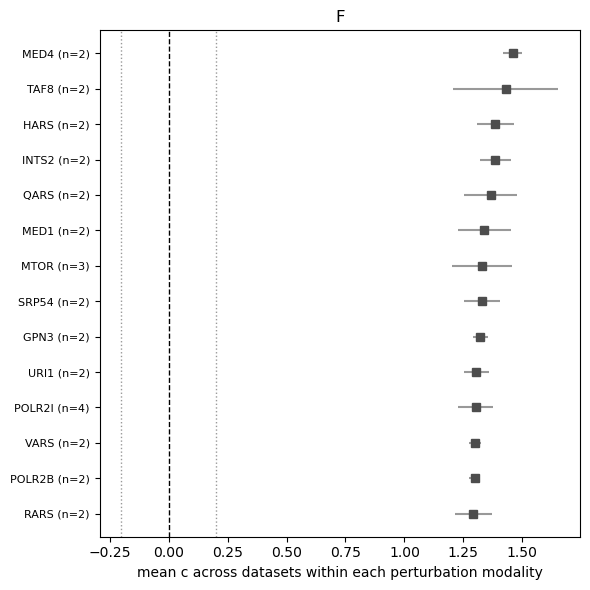

In [8]:
R.panel_f()

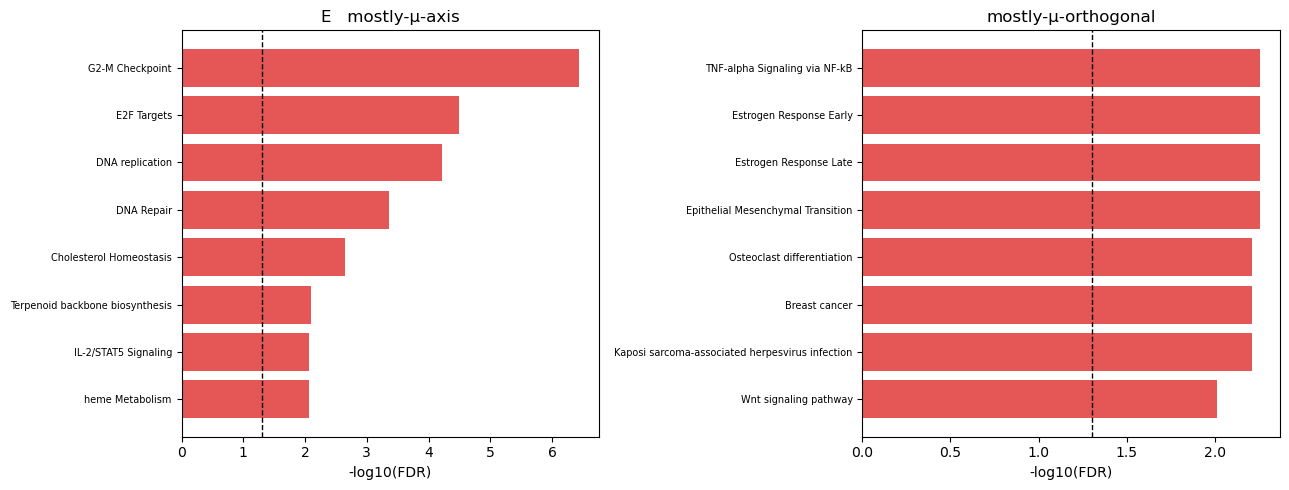

In [9]:
# E -- GSEA/Enrichr of the mu-axis-dominated targets (needs network; skipped gracefully offline).
try:
    R.panel_e_gsea()
except Exception as _e:
    print("panel_e_gsea skipped:", repr(_e))